<a href="https://colab.research.google.com/github/dev-anju/ParkZen/blob/main/parkZen_with_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

In [ ]:
!unzip -q /content/dataset.zip -d /content/

error [/content/dataset.zip]:  missing 51380224 bytes in zipfile
  (attempting to process anyway)
error: invalid zip file with overlapped components (possible zip bomb)


In [ ]:
!find /content -type d -name "train"

/content/train


In [ ]:
!find /content -name "data.yaml"

/content/data.yaml


In [ ]:
import os

base_path = "/content"

for folder in ["train", "valid", "test"]:
    print(f"\n{folder.upper()}")
    print("Images:", len(os.listdir(f"{base_path}/{folder}/images")))
    print("Labels:", len(os.listdir(f"{base_path}/{folder}/labels")))


TRAIN
Images: 8691
Labels: 8691

VALID
Images: 2483
Labels: 2483

TEST
Images: 1242
Labels: 1242


In [ ]:
from PIL import Image
import os

base_path = "/content"

bad_images = []

for folder in ["train", "valid", "test"]:
    img_dir = os.path.join(base_path, folder, "images")

    for img in os.listdir(img_dir):
        try:
            Image.open(os.path.join(img_dir, img)).verify()
        except:
            bad_images.append(os.path.join(img_dir, img))

print("Corrupted images:", len(bad_images))

if bad_images:
    for img in bad_images[:10]:
        print(img)

Corrupted images: 0


In [ ]:
import os

base_path = "/content"

empty_labels = []

for folder in ["train", "valid", "test"]:
    label_dir = os.path.join(base_path, folder, "labels")
    for label in os.listdir(label_dir):
        path = os.path.join(label_dir, label)

        if os.path.getsize(path) == 0:
            empty_labels.append(path)

print("Empty label files:", len(empty_labels))

Empty label files: 274


In [ ]:
from collections import Counter
import os

counter = Counter()

for folder in ["train", "valid", "test"]:
    label_dir = os.path.join("/content", folder, "labels")

    for file in os.listdir(label_dir):
        with open(os.path.join(label_dir, file), "r") as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    counter[cls] += 1

print(counter)

Counter({0: 376121, 1: 335735})


Total empty label images: 274
/content/train/images/2012-12-28_10_15_05_jpg.rf.07a6c552d84afcecb89a0ee070829af4.jpg


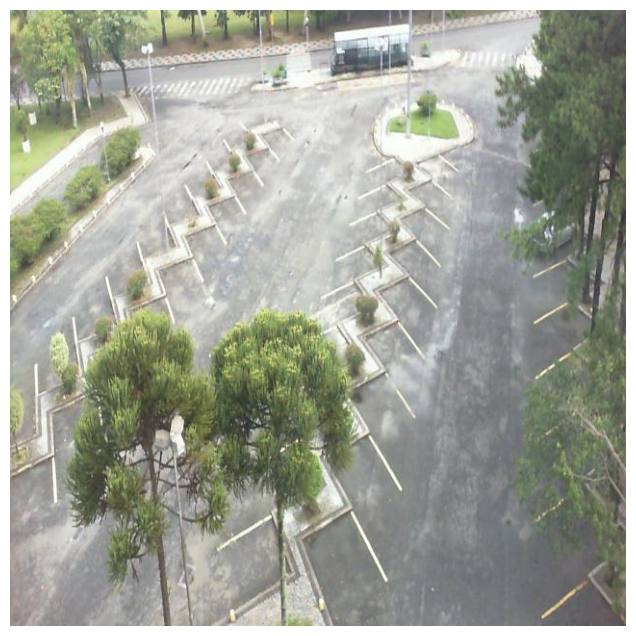

In [ ]:
import random
import os
from PIL import Image
import matplotlib.pyplot as plt

base_path = "/content"

empty = []

for folder in ["train", "valid", "test"]:
    label_dir = os.path.join(base_path, folder, "labels")

    for label in os.listdir(label_dir):
        path = os.path.join(label_dir, label)
        if os.path.getsize(path) == 0:
            image_name = os.path.splitext(label)[0] + ".jpg"
            image_path = os.path.join(base_path, folder, "images", image_name)

            if os.path.exists(image_path):
                empty.append(image_path)

print("Total empty label images:", len(empty))

img = random.choice(empty)
print(img)

plt.figure(figsize=(8,8))
plt.imshow(Image.open(img))
plt.axis("off")
plt.show()

In [ ]:
import os

image = "/content/train/images/2012-12-28_17_35_13_jpg.rf.6e06e01393ab5bf93e12cd8701ec5919.jpg"

label = image.replace("/images/", "/labels/").replace(".jpg", ".txt")

print("Label exists:", os.path.exists(label))

if os.path.exists(label):
    print("Label file size:", os.path.getsize(label))
    with open(label, "r") as f:
        print("Contents:")
        print(repr(f.read()))

Label exists: True
Label file size: 0
Contents:
''


In [ ]:
from collections import Counter
import os

counter = Counter()

for folder in ["train", "valid", "test"]:
    label_dir = os.path.join("/content", folder, "labels")

    for file in os.listdir(label_dir):
        with open(os.path.join(label_dir, file), "r") as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    counter[cls] += 1

print(counter)

Counter({0: 376121, 1: 335735})


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    epochs=1,
    imgsz=640,
    batch=16,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e7e8cded220>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
import os
import random

label_folder = "/content/train/labels"

non_empty = []

for file in os.listdir(label_folder):
    path = os.path.join(label_folder, file)
    if os.path.getsize(path) > 0:
        non_empty.append(path)

print("Non-empty labels:", len(non_empty))

sample = random.choice(non_empty)

print("\nSample label file:")
print(sample)

with open(sample, "r") as f:
    print(f.read())

Non-empty labels: 8502

Sample label file:
/content/train/labels/2013-04-11_13_55_08_jpg.rf.8705fe3e7a63c8d26e1ee5042f831133.txt
1 0.540625 0.81953125 0.13046875 0.178125
1 0.4828125 0.67890625 0.11953125 0.1390625
1 0.4359375 0.57109375 0.10546875 0.125
1 0.3984375 0.47890625 0.09921875 0.1140625
1 0.3640625 0.39453125 0.090625 0.0890625
1 0.34375 0.3203125 0.08828125 0.090625
1 0.309375 0.2546875 0.08359375 0.0765625
1 0.284375 0.19609375 0.07578125 0.078125
1 0.27109375 0.1484375 0.071875 0.0640625
1 0.25078125 0.103125 0.0671875 0.0640625
1 0.6234375 0.728125 0.10546875 0.128125
1 0.55078125 0.6125 0.1109375 0.121875
1 0.51875 0.50390625 0.09453125 0.10859375
1 0.475 0.415625 0.1015625 0.096875
1 0.44453125 0.3421875 0.0953125 0.084375
1 0.41484375 0.271875 0.090625 0.08046875
1 0.3859375 0.2171875 0.07734375 0.06796875
1 0.359375 0.16015625 0.08671875 0.0765625
1 0.334375 0.11796875 0.06953125 0.05546875
1 0.3078125 0.07734375 0.06953125 0.05703125
1 0.884375 0.52890625 0.0765625 

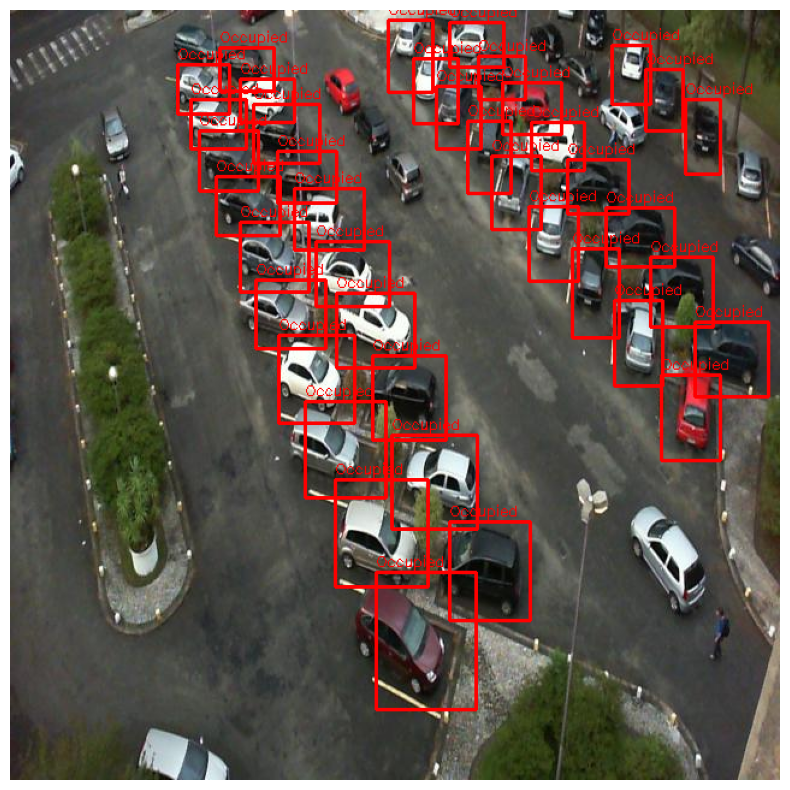

In [ ]:
import cv2
import random
import os
import matplotlib.pyplot as plt

base = "/content"

# Random image
img_name = random.choice(os.listdir(f"{base}/train/images"))

img_path = os.path.join(base, "train/images", img_name)
label_path = os.path.join(base, "train/labels",
                          os.path.splitext(img_name)[0] + ".txt")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

if os.path.exists(label_path):
    with open(label_path) as f:
        for line in f:
            if line.strip():

                cls, xc, yc, bw, bh = map(float, line.split())

                xc *= w
                yc *= h
                bw *= w
                bh *= h

                x1 = int(xc - bw/2)
                y1 = int(yc - bh/2)
                x2 = int(xc + bw/2)
                y2 = int(yc + bh/2)

                color = (0,255,0) if int(cls)==0 else (255,0,0)

                cv2.rectangle(img,(x1,y1),(x2,y2),color,2)

                label = "Empty" if int(cls)==0 else "Occupied"

                cv2.putText(img,label,(x1,y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.4,color,1)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import os
import cv2
from collections import Counter

image_folder = "/content/train/images"

sizes = []

for img in os.listdir(image_folder):
    path = os.path.join(image_folder, img)
    image = cv2.imread(path)

    if image is not None:
        h, w = image.shape[:2]
        sizes.append((w, h))

counter = Counter(sizes)

print("Different image sizes found:")
for size, count in counter.items():
    print(size, ":", count)

Different image sizes found:
(640, 640) : 8691


In [ ]:
import os
import hashlib

folder = "/content/train/images"

hashes = {}
duplicates = []

for filename in os.listdir(folder):
    filepath = os.path.join(folder, filename)

    with open(filepath, "rb") as f:
        filehash = hashlib.md5(f.read()).hexdigest()

    if filehash in hashes:
        duplicates.append((filename, hashes[filehash]))
    else:
        hashes[filehash] = filename

print("Duplicate Images:", len(duplicates))

Duplicate Images: 0


In [ ]:
import os
import cv2

folder = "/content/train/images"

blur_images = []

for img in os.listdir(folder):

    path = os.path.join(folder, img)

    image = cv2.imread(path)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    score = cv2.Laplacian(gray, cv2.CV_64F).var()

    if score < 100:
        blur_images.append((img, score))

print("Blurry Images:", len(blur_images))

Blurry Images: 38


In [ ]:
import os
import cv2
import numpy as np

folder="/content/train/images"

dark=0
bright=0
normal=0

for img in os.listdir(folder):

    image=cv2.imread(os.path.join(folder,img))

    gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

    mean=np.mean(gray)

    if mean<50:
        dark+=1
    elif mean>200:
        bright+=1
    else:
        normal+=1

print("Dark Images :",dark)
print("Bright Images :",bright)
print("Normal Images :",normal)

Dark Images : 0
Bright Images : 84
Normal Images : 8607


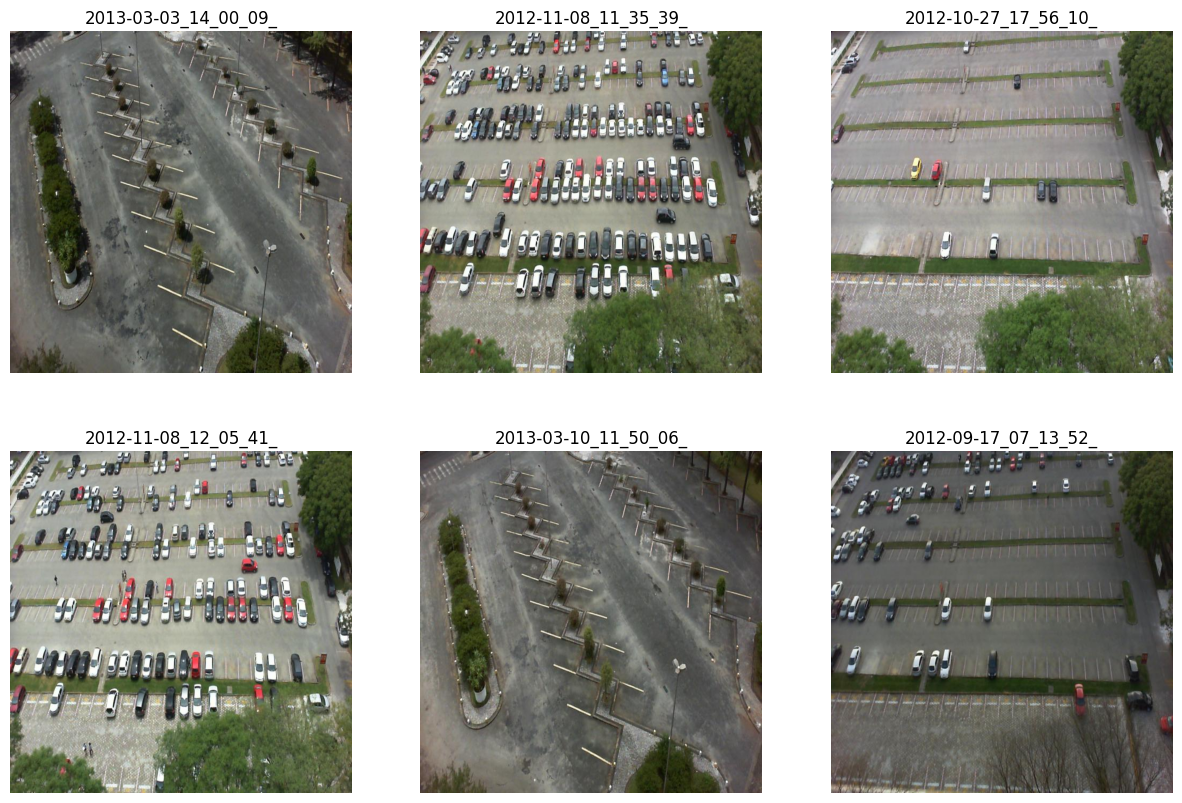

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

folder="/content/train/images"

samples=random.sample(os.listdir(folder),6)

plt.figure(figsize=(15,10))

for i,img in enumerate(samples):

    image=cv2.imread(os.path.join(folder,img))
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(img[:20])
    plt.axis("off")

plt.show()

In [ ]:
import os
import shutil

folder = "/content/train/images"
label_folder = "/content/train/labels"

os.makedirs("/content/removed_blurry/images", exist_ok=True)
os.makedirs("/content/removed_blurry/labels", exist_ok=True)

for img, score in blur_images:
    shutil.move(os.path.join(folder, img),
                os.path.join("/content/removed_blurry/images", img))

    label = img.replace(".jpg", ".txt").replace(".png", ".txt").replace(".jpeg", ".txt")
    if os.path.exists(os.path.join(label_folder, label)):
        shutil.move(os.path.join(label_folder, label),
                    os.path.join("/content/removed_blurry/labels", label))

print("Moved", len(blur_images), "blurry images.")

Moved 38 blurry images.


In [ ]:
import os

label_dirs = [
    "/content/train/labels",
    "/content/valid/labels",
    "/content/test/labels"
]

invalid = 0

for folder in label_dirs:
    for file in os.listdir(folder):
        if not file.endswith(".txt"):
            continue

        with open(os.path.join(folder, file)) as f:
            for line in f:
                if line.strip() == "":
                    continue

                cls, x, y, w, h = map(float, line.split())

                if not (0 <= x <= 1 and
                        0 <= y <= 1 and
                        0 < w <= 1 and
                        0 < h <= 1):
                    invalid += 1
                    print("Invalid:", file, line.strip())

print("Total invalid boxes:", invalid)

Total invalid boxes: 0


In [ ]:
import os

for folder in ["train", "valid", "test"]:
    print(f"\n{folder.upper()}")
    print("Images:", len(os.listdir(f"/content/{folder}/images")))
    print("Labels:", len(os.listdir(f"/content/{folder}/labels")))


TRAIN
Images: 8653
Labels: 8653

VALID
Images: 2483
Labels: 2483

TEST
Images: 1242
Labels: 1242


In [ ]:
!cat /content/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['space-empty', 'space-occupied']

roboflow:
  workspace: brad-dwyer
  project: pklot-1tros
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/brad-dwyer/pklot-1tros/dataset/2

In [ ]:
%%writefile /content/data.yaml

path: /content

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied

Overwriting /content/data.yaml


In [ ]:
!cat /content/data.yaml


path: /content

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: space-empty
  1: space-occupied


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

In [ ]:
results = model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    name="parking_detection"
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parking_detection, nbs=64, nms=False, opset=None, optimize=Fals

In [ ]:
!cp -r /content/runs /content/drive/MyDrive/ParkingProject/

cp: cannot stat '/content/runs': No such file or directory


In [ ]:
metrics = model.val()
print(metrics)

NameError: name 'model' is not defined